In [1]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de clasificación
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier
from xgboost import XGBClassifier

# Para trabajar redes con Keras.
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import Dense

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# para hacer la curva ROC
from sklearn.metrics            import roc_auc_score
from sklearn.metrics            import roc_curve

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV

import time

# Guardar modelos
import joblib
import os

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [3]:
credit_df = pd.read_csv(path + "/creditcard.csv")
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
credit_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
credit_df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [6]:
fraudes = credit_df['Class'].sum()
total = len(credit_df)
fraudes_pct = fraudes / total * 100

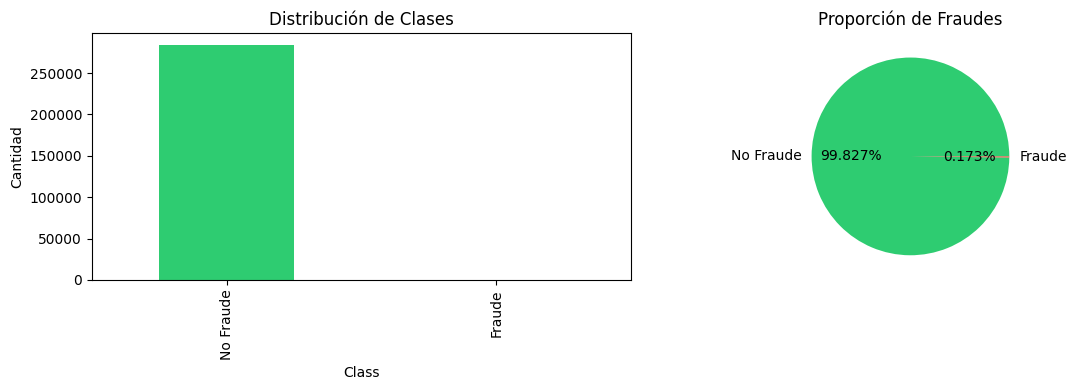

In [7]:
# 2.3 Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
credit_df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ECC71', '#E74C3C'])
axes[0].set_title('Distribución de Clases')
axes[0].set_xticklabels(['No Fraude', 'Fraude'])
axes[0].set_ylabel('Cantidad')

# Pie chart
credit_df['Class'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.3f%%',
                                 colors=['#2ECC71', '#E74C3C'], labels=['No Fraude', 'Fraude'])
axes[1].set_title('Proporción de Fraudes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [8]:
# 2.4 Análisis de Amount
print("Análisis de Amount:")
print(f"   Amount promedio: ${credit_df['Amount'].mean():.2f}")
print(f"   Amount promedio (fraudes): ${credit_df[credit_df['Class']==1]['Amount'].mean():.2f}")
print(f"   Amount promedio (no fraudes): ${credit_df[credit_df['Class']==0]['Amount'].mean():.2f}")

Análisis de Amount:
   Amount promedio: $88.35
   Amount promedio (fraudes): $122.21
   Amount promedio (no fraudes): $88.29


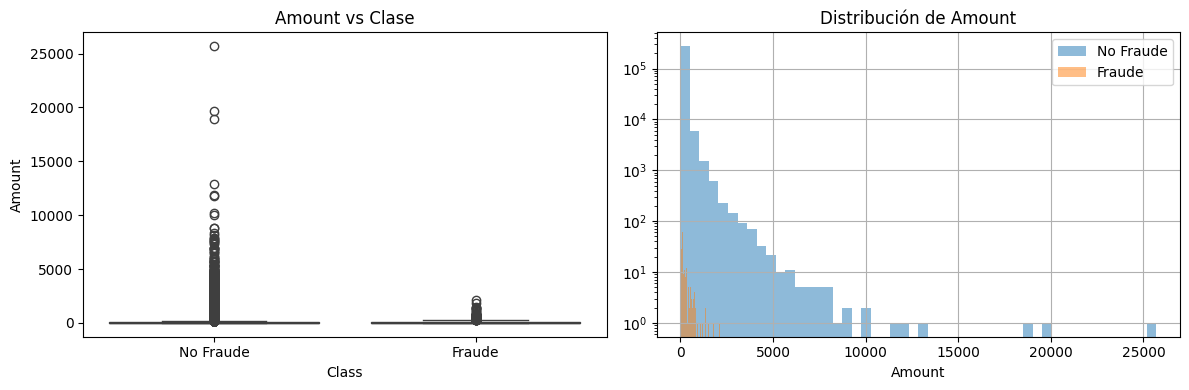

In [9]:
# 2.5 Distribución de Amount por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
sns.boxplot(x='Class', y='Amount', data=credit_df, ax=axes[0])
axes[0].set_title('Amount vs Clase')
axes[0].set_xticklabels(['No Fraude', 'Fraude'])

# Histograma (log scale)
credit_df[credit_df['Class']==0]['Amount'].hist(bins=50, alpha=0.5, label='No Fraude', ax=axes[1])
credit_df[credit_df['Class']==1]['Amount'].hist(bins=50, alpha=0.5, label='Fraude', ax=axes[1])
axes[1].set_title('Distribución de Amount')
axes[1].set_xlabel('Amount')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

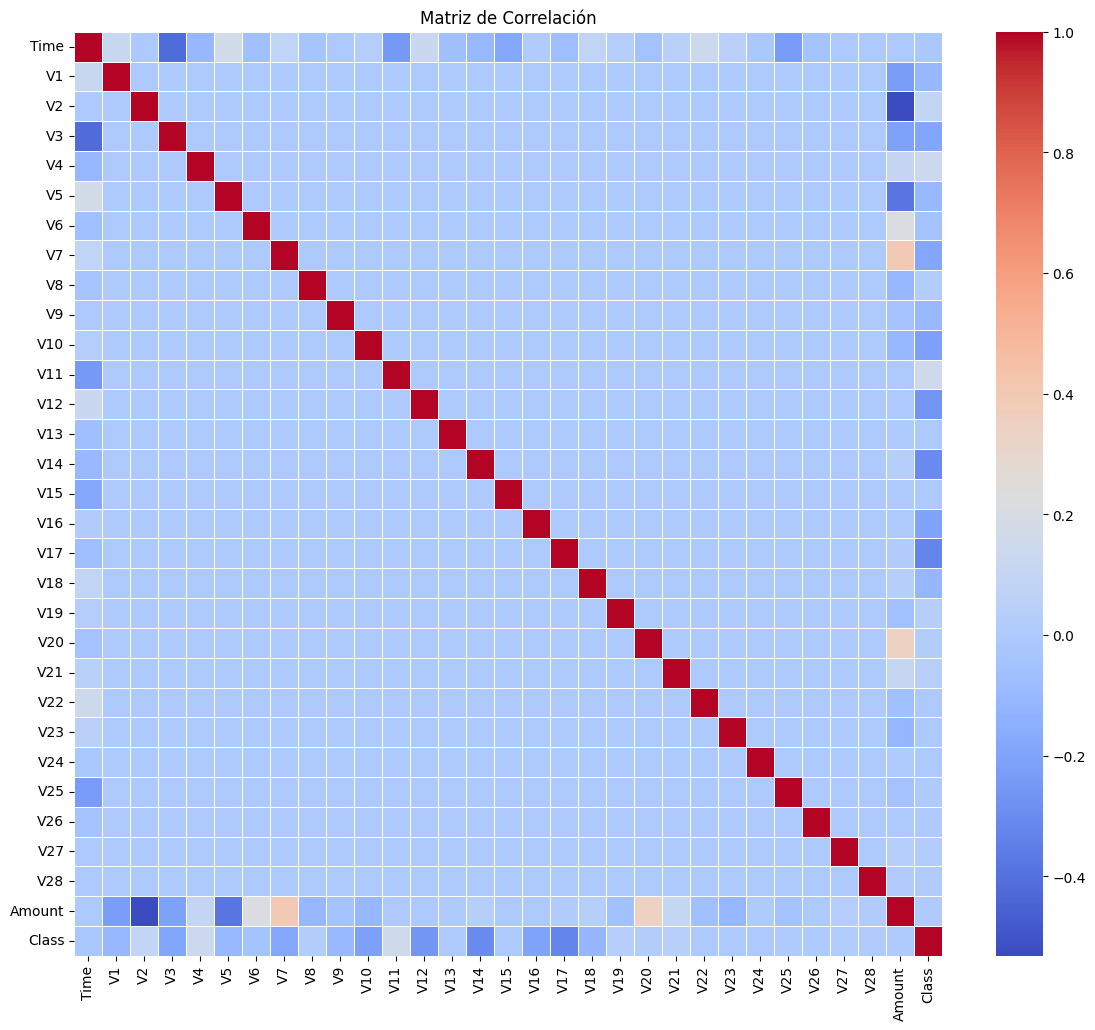

In [10]:
# 2.6 Matriz de correlación
plt.figure(figsize=(14, 12))
corr = credit_df.corr()
sns.heatmap(corr, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [11]:
# 1. Dividir en dos conjuntos
# las variables predictoras
X = credit_df.drop('Class', axis=1)
# la variable objetivo
y = credit_df['Class']

In [12]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [13]:
# 3. Conjunto de entrenamiento, validación y prueba, Datos desbalanciados
#1. PRIMERA DIVISIÓN: Train (60%) y Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
                                                    X,                          # variables predictoras
                                                    y,                          # variable de respuesta
                                                    stratify=y,                 # estratificamos con respecto a y
                                                    test_size=0.4,              # 20% para temp (que luego se divide en val y test)
                                                    random_state=42             # semilla para reproducibilidad
                                                )
#2. SEGUNDA DIVISIÓN: Temp → Validation (50%) y Test (50%)
X_val, X_test, y_val, y_test = train_test_split(
                                                X_temp,                     # datos temporales
                                                y_temp,                     # etiquetas temporales
                                                stratify=y_temp,            # estratificamos con respecto a y_temp
                                                test_size=0.5,              # 50% de Temp = 10% del total para Test
                                                random_state=42             # semilla para reproducibilidad
                                              )
# 3. ESCALAR DESPUÉS (¡NUEVO ORDEN!)
scaler = StandardScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_val[['Amount', 'Time']] = scaler.transform(X_val[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

In [14]:
#APLICAREMOS 3 MODELOS:
# 1. Undersampling (456 datos Fraude, 456 datos no fraude) - Perdida de información en identificar no fraudes
# 2. Combinación con SMOTE sin generar muchos datos sinteticos. (5000 datos fraude (sinteticos/reales)), (5000 datos no fraude)
# 3. Red Neuronal con datos en pesos

In [15]:
#MODELO 1
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [16]:
undersample = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_train_bal1, y_train_bal1 = undersample.fit_resample(X_train, y_train)

In [17]:
# Verificar balance
print(pd.Series(y_train_bal1).value_counts())

Class
0    295
1    295
Name: count, dtype: int64


In [18]:
# Configurar XGBoost con regularización EXTREMA (porque hay pocos datos)

import xgboost as xgb # New import for the lower-level API

# Define parameters for xgb.train (similar to XGBClassifier parameters)
params = {
    'objective': 'binary:logistic', # Specify objective for binary classification
    'eval_metric': 'logloss',       # Evaluation metric
    'max_depth': 3,
    'learning_rate': 0.03,
    'subsample': 0.6,
    'colsample_bytree': 0.6,
    'reg_alpha': 2.0,
    'reg_lambda': 3.0,
    'min_child_weight': 5,
    'seed': 42 # 'random_state' for XGBClassifier maps to 'seed' for xgb.train
}

num_boost_round = 200 # Corresponds to n_estimators in XGBClassifier

# Create DMatrix objects for train and validation
dtrain = xgb.DMatrix(X_train_bal1, label=y_train_bal1)
dval = xgb.DMatrix(X_val, label=y_val)

eval_set_dmatrix = [(dtrain, 'train'), (dval, 'validation')] # Use DMatrix for eval_set

print("Starting xgb.train with early stopping...")
# Train the model using xgb.train
modelo_xgb_256_booster = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=eval_set_dmatrix,
    early_stopping_rounds=10, # early stopping rounds for xgb.train
    verbose_eval=True # Muestra progreso
)
print("xgb.train completed.")

# Create a new XGBClassifier instance with the best number of boosting rounds
# to ensure compatibility with the 'evaluacion_modelo' function.
modelo_XGB = XGBClassifier(
    objective='binary:logistic', # Specify objective for binary classification
    eval_metric='logloss',       # Evaluation metric
    max_depth=3,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=2.0,
    reg_lambda=3.0,
    min_child_weight=5,
    n_estimators=modelo_xgb_256_booster.best_iteration + 1, # Use the best iteration from xgb.train
    random_state=42,
    use_label_encoder=False,
    verbosity=0
)

# Fit this new XGBClassifier. This step effectively loads the best booster's state
# into the XGBClassifier object, allowing it to be used with scikit-learn compatible functions.
modelo_XGB.fit(X_train_bal1, y_train_bal1)

Starting xgb.train with early stopping...
[0]	train-logloss:0.67234	validation-logloss:0.67428
[1]	train-logloss:0.65253	validation-logloss:0.65428
[2]	train-logloss:0.63344	validation-logloss:0.63534
[3]	train-logloss:0.61500	validation-logloss:0.61688
[4]	train-logloss:0.59892	validation-logloss:0.59985
[5]	train-logloss:0.58214	validation-logloss:0.58197
[6]	train-logloss:0.56650	validation-logloss:0.56740
[7]	train-logloss:0.55225	validation-logloss:0.55344
[8]	train-logloss:0.53848	validation-logloss:0.54089
[9]	train-logloss:0.52605	validation-logloss:0.52837
[10]	train-logloss:0.51336	validation-logloss:0.51674
[11]	train-logloss:0.50097	validation-logloss:0.50503
[12]	train-logloss:0.48934	validation-logloss:0.49338
[13]	train-logloss:0.47797	validation-logloss:0.48297
[14]	train-logloss:0.46720	validation-logloss:0.47302
[15]	train-logloss:0.45705	validation-logloss:0.46223
[16]	train-logloss:0.44687	validation-logloss:0.45220
[17]	train-logloss:0.43762	validation-logloss:0.44

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
#Definimos una función para hacer más agil el proceso de
#Definir conjuntos Train, Test
#Matrices de confusión (Calcularla y graficarla con heatmap) en Train y Test
#Metricas en Train y Valores en un tabla Knn_train vs Knn_test
def evaluacion_modelo(modelo, X_train, y_train, X_val, y_val, nombre_modelo = "modelo", graficar = True):
  # definir las predicciones en conjuntos de train y validation
  y_pred_train = modelo.predict(X_train)
  y_pred_val  = modelo.predict(X_val)
  # matrices de confusión
  if graficar :
    # Calcular matrices de confusión
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_val = confusion_matrix(y_val, y_pred_val)
    # ejes para gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # matriz de confusión en train
    sns.heatmap(pd.DataFrame(cm_train),                # data.frame
                  annot=True,                          # colocar números de las cajitas
                  annot_kws = {'size':20},             # tamaño de la letra
                  cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                  fmt='g',                             # para que salgan los número no : notación científica
                  ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - Train-{nombre_modelo}', fontsize=14)
    axes[0].set_xlabel('Predicciones')
    axes[0].set_ylabel('Valores Reales')
    # matriz de confusión en validation
    sns.heatmap(pd.DataFrame(cm_val),
              annot=True,
              fmt='g',
              cmap='YlOrRd',
              annot_kws={'size':16},
              ax=axes[1])
    axes[1].set_title(f'Matriz de Confusión - Validation-{nombre_modelo}', fontsize=14)
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Valores Reales')
    plt.tight_layout()
    plt.show()
  # metricas en train
  metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
  # valores
  values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
  values_val = [accuracy_score(y_val,y_pred_val),
          recall_score(y_val,y_pred_val),
          specificity_score(y_val,y_pred_val),
          precision_score(y_val,y_pred_val),
          f1_score(y_val,y_pred_val)]

  df = pd.DataFrame({f"{nombre_modelo}_train" : values_train,
                      f"{nombre_modelo}_validation" : values_val}, index = metrics)
  return df


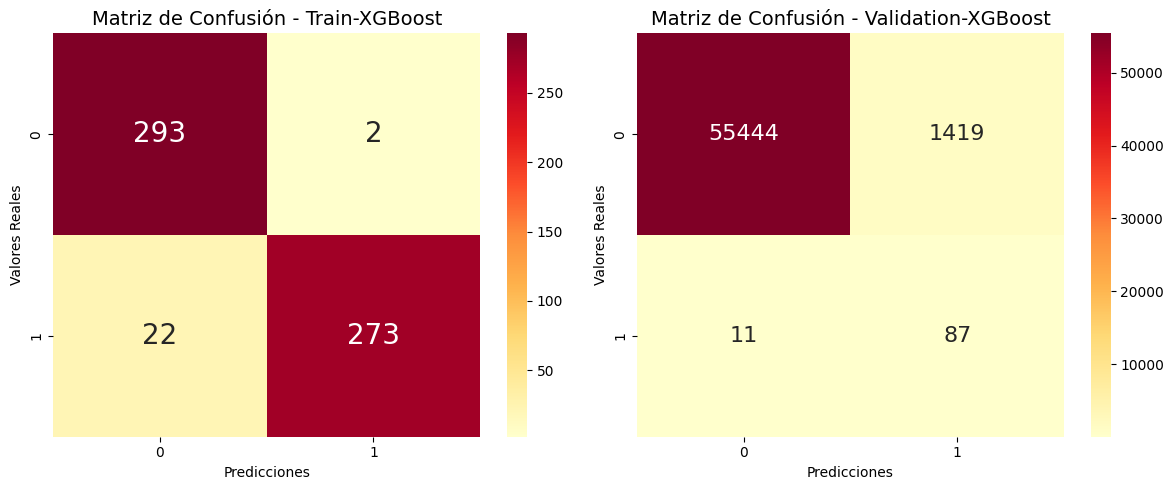

,XGBoost_train,XGBoost_validation
accuracy,0.959322,0.974895
recall,0.925424,0.887755
specificity,0.993220,0.975045
precision,0.992727,0.057769
f1,0.957895,0.108479


In [20]:
#Evaluación modelo XGB UnderSampling
metricas_XGB = evaluacion_modelo(modelo_XGB, X_train_bal1, y_train_bal1, X_val, y_val, nombre_modelo = "XGBoost", graficar = True)
metricas_XGB

In [21]:
#MODELO 2 - 5000 MIL / 5000 MIL

In [22]:
# Paso 1: Submuestreo de no-fraudulentos a 5,000
undersample = RandomUnderSampler(sampling_strategy={0: 5000}, random_state=42)
X_train_sub, y_train_sub = undersample.fit_resample(X_train, y_train)

In [23]:
# Paso 2: Sobremuestreo con SMOTE para llegar a 5,000 fraudulentos
smote = SMOTE(sampling_strategy={1: 5000}, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sub, y_train_sub)

In [24]:
# 3. CONFIGURAR XGBOOST CON EARLY STOPPING
modelo_xgb_5000 = xgb.XGBClassifier(
    # Parámetros de regularización (moderados, porque hay más datos)
    max_depth=4,                # Árboles moderadamente profundos
    learning_rate=0.05,         # Aprendizaje moderado
    subsample=0.8,              # Usa 80% de filas en cada árbol
    colsample_bytree=0.8,       # Usa 80% de columnas en cada árbol
    reg_alpha=1.0,              # Regularización L1
    reg_lambda=2.0,             # Regularización L2
    min_child_weight=3,         # Mínimo peso por hoja

    # Parámetros generales
    n_estimators=500,           # Máximo de árboles (early stopping cortará)
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0,
    early_stopping_rounds=20,
)
# Entrenar con early stopping (20 rondas de paciencia)
eval_set = [(X_train_bal, y_train_bal), (X_val, y_val)]

modelo_xgb_5000.fit(
    X_train_bal, y_train_bal,
    eval_set=eval_set,
    verbose=True                # Muestra progreso
)

[0]	validation_0-logloss:0.65246	validation_1-logloss:0.65267
[1]	validation_0-logloss:0.61540	validation_1-logloss:0.61549
[2]	validation_0-logloss:0.58175	validation_1-logloss:0.58197
[3]	validation_0-logloss:0.55104	validation_1-logloss:0.55150
[4]	validation_0-logloss:0.52265	validation_1-logloss:0.52303
[5]	validation_0-logloss:0.49671	validation_1-logloss:0.49695
[6]	validation_0-logloss:0.47281	validation_1-logloss:0.47259
[7]	validation_0-logloss:0.45032	validation_1-logloss:0.45021
[8]	validation_0-logloss:0.42958	validation_1-logloss:0.42895
[9]	validation_0-logloss:0.41044	validation_1-logloss:0.40975
[10]	validation_0-logloss:0.39229	validation_1-logloss:0.39144
[11]	validation_0-logloss:0.37543	validation_1-logloss:0.37419
[12]	validation_0-logloss:0.35980	validation_1-logloss:0.35855
[13]	validation_0-logloss:0.34502	validation_1-logloss:0.34379
[14]	validation_0-logloss:0.33115	validation_1-logloss:0.32946
[15]	validation_0-logloss:0.31806	validation_1-logloss:0.31616
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

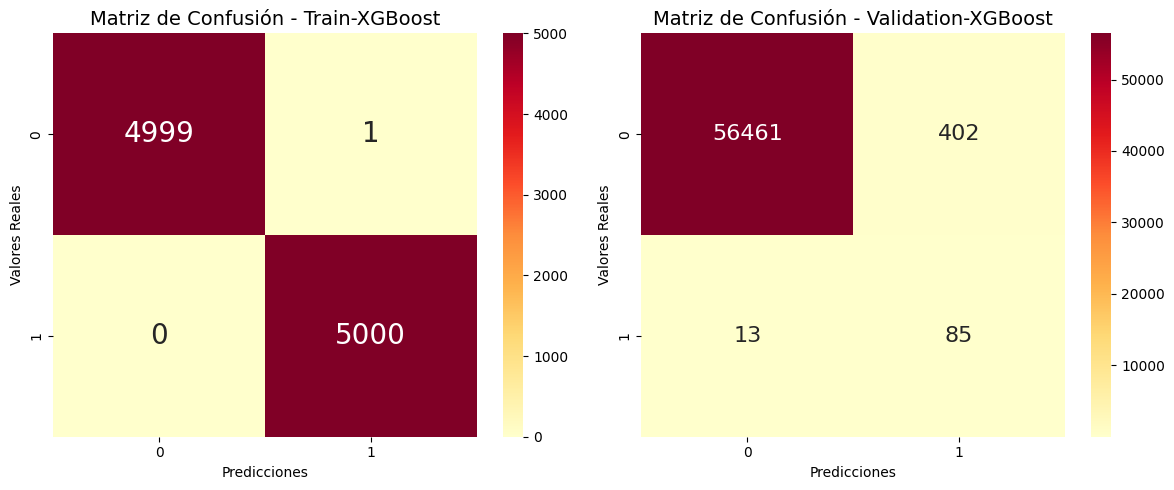

,XGBoost_train,XGBoost_validation
accuracy,0.9999,0.992714
recall,1.0000,0.867347
specificity,0.9998,0.992930
precision,0.9998,0.174538
f1,0.9999,0.290598


In [25]:
#Evaluación modelo 2 - Oversampling
metricas_XGB_2 = evaluacion_modelo(modelo_xgb_5000, X_train_bal, y_train_bal, X_val, y_val, nombre_modelo = "XGBoost", graficar = True)
metricas_XGB_2

In [26]:
#MODELO 3 - APLICANDO SMOTE

In [27]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_bal2, y_train_bal2 = smote.fit_resample(X_train, y_train)

In [28]:
# Verificar balance
print(pd.Series(y_train_bal2).value_counts())

Class
0    170589
1    170589
Name: count, dtype: int64


In [29]:
# 3. CONFIGURAR XGBOOST CON EARLY STOPPING
modelo_xgb_SF = xgb.XGBClassifier(
    # Parámetros de regularización (moderados, porque hay más datos)
    max_depth=4,                # Árboles moderadamente profundos
    learning_rate=0.05,         # Aprendizaje moderado
    subsample=0.8,              # Usa 80% de filas en cada árbol
    colsample_bytree=0.8,       # Usa 80% de columnas en cada árbol
    reg_alpha=1.0,              # Regularización L1
    reg_lambda=2.0,             # Regularización L2
    min_child_weight=3,         # Mínimo peso por hoja

    # Parámetros generales
    n_estimators=500,           # Máximo de árboles (early stopping cortará)
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0,
    early_stopping_rounds=20,
)
# Entrenar con early stopping (20 rondas de paciencia)
eval_set = [(X_train_bal2, y_train_bal2), (X_val, y_val)]

modelo_xgb_SF.fit(
    X_train_bal2, y_train_bal2,
    eval_set=eval_set,
    verbose=True                # Muestra progreso
)

[0]	validation_0-logloss:0.65215	validation_1-logloss:0.65209
[1]	validation_0-logloss:0.61456	validation_1-logloss:0.61433
[2]	validation_0-logloss:0.58036	validation_1-logloss:0.57993
[3]	validation_0-logloss:0.54910	validation_1-logloss:0.54836
[4]	validation_0-logloss:0.52043	validation_1-logloss:0.51931
[5]	validation_0-logloss:0.49417	validation_1-logloss:0.49265
[6]	validation_0-logloss:0.46991	validation_1-logloss:0.46790
[7]	validation_0-logloss:0.44795	validation_1-logloss:0.44551
[8]	validation_0-logloss:0.42712	validation_1-logloss:0.42419
[9]	validation_0-logloss:0.40781	validation_1-logloss:0.40438
[10]	validation_0-logloss:0.38975	validation_1-logloss:0.38595
[11]	validation_0-logloss:0.37297	validation_1-logloss:0.36869
[12]	validation_0-logloss:0.35729	validation_1-logloss:0.35252
[13]	validation_0-logloss:0.34259	validation_1-logloss:0.33738
[14]	validation_0-logloss:0.32886	validation_1-logloss:0.32328
[15]	validation_0-logloss:0.31609	validation_1-logloss:0.31010
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

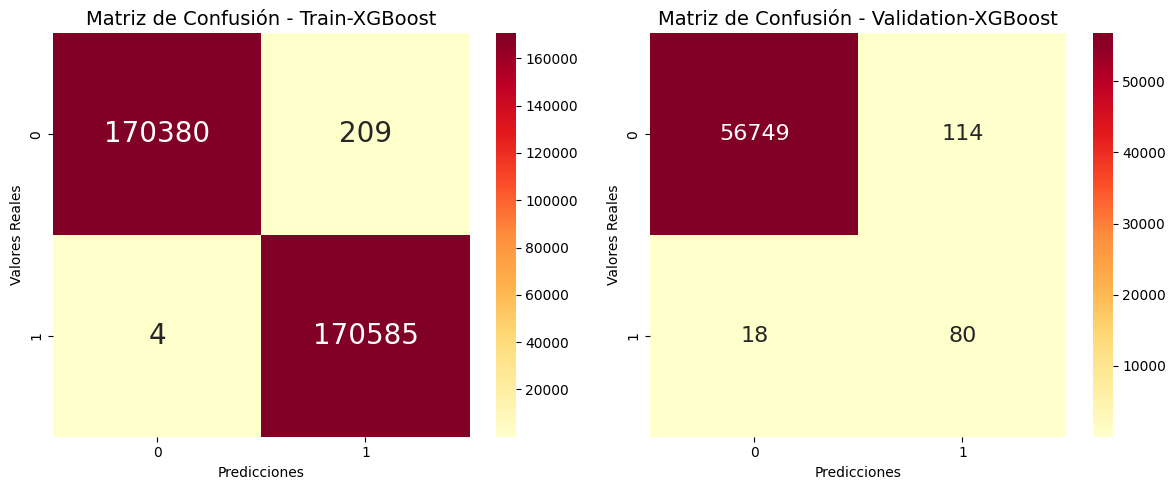

,XGBoost_train,XGBoost_validation
accuracy,0.959322,0.974895
recall,0.925424,0.887755
specificity,0.993220,0.975045
precision,0.992727,0.057769
f1,0.957895,0.108479


In [30]:
#Evaluación modelo 3 - SMOTE full
metricas_XGB_3 = evaluacion_modelo(modelo_xgb_SF, X_train_bal2, y_train_bal2, X_val, y_val, nombre_modelo = "XGBoost", graficar = True)
metricas_XGB


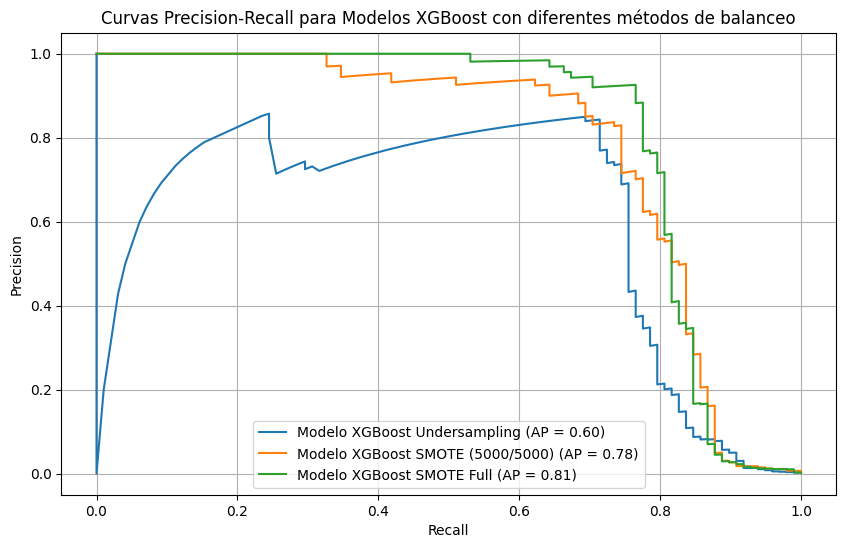

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

#Precision-Recall Curve para los 3 modelos XGB con 3 diferentes metodos de balanceo
plt.figure(figsize=(10, 6))

# Modelo 1: modelo_XGB (undersampling)
y_prob_1 = modelo_XGB.predict_proba(X_val)[:, 1]
precision_1, recall_1, _ = precision_recall_curve(y_val, y_prob_1)
ap_score_1 = average_precision_score(y_val, y_prob_1)
plt.plot(recall_1, precision_1, label=f'Modelo XGBoost Undersampling (AP = {ap_score_1:.2f})')

# Modelo 2: modelo_xgb_5000 (undersampling + SMOTE 5000/5000)
y_prob_2 = modelo_xgb_5000.predict_proba(X_val)[:, 1]
precision_2, recall_2, _ = precision_recall_curve(y_val, y_prob_2)
ap_score_2 = average_precision_score(y_val, y_prob_2)
plt.plot(recall_2, precision_2, label=f'Modelo XGBoost SMOTE (5000/5000) (AP = {ap_score_2:.2f})')

# Modelo 3: modelo_xgb_SF (SMOTE full)
y_prob_3 = modelo_xgb_SF.predict_proba(X_val)[:, 1]
precision_3, recall_3, _ = precision_recall_curve(y_val, y_prob_3)
ap_score_3 = average_precision_score(y_val, y_prob_3)
plt.plot(recall_3, precision_3, label=f'Modelo XGBoost SMOTE Full (AP = {ap_score_3:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall para Modelos XGBoost con diferentes métodos de balanceo')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [32]:
#La estrategia de balanceo mediante SMOTE aplicado al conjunto completo obtuvo el mejor desempeño,
#alcanzando un Average Precision de 0.81, superando tanto al modelo entrenado con undersampling (0.60) como al modelo SMOTE 5000/5000 (0.78).

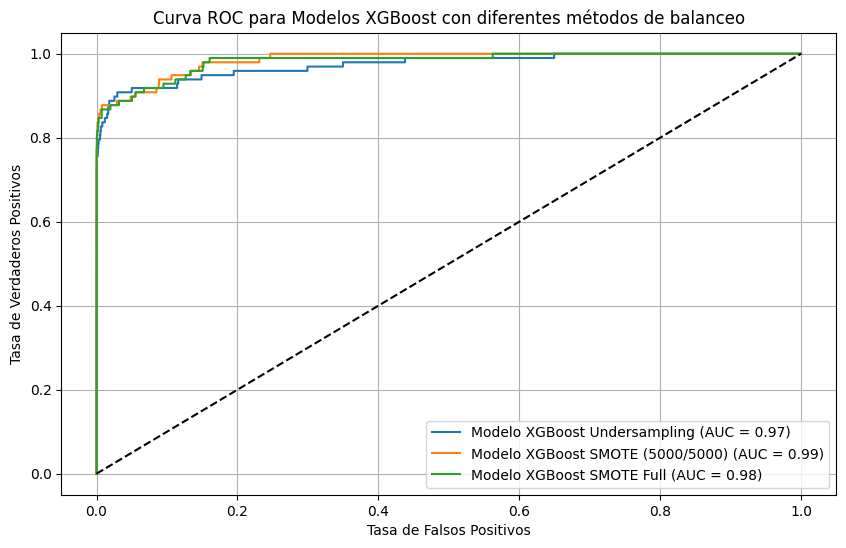

In [33]:
# CÁLCULO DE ROC Y AUC EN VALIDATION
# Curva ROC - Validation
fpr_xgb_256, tpr_xgb_256, _ = roc_curve(y_val, modelo_XGB.predict_proba(X_val)[:, 1])
fpr_xgb_5000, tpr_xgb_5000, _ = roc_curve(y_val, modelo_xgb_5000.predict_proba(X_val)[:, 1])
fpr_xgb_SF, tpr_xgb_SF, _ = roc_curve(y_val, modelo_xgb_SF.predict_proba(X_val)[:, 1])
# AUC - Validation
auc_xgb_256 = roc_auc_score(y_val, modelo_XGB.predict_proba(X_val)[:, 1])
auc_xgb_5000 = roc_auc_score(y_val, modelo_xgb_5000.predict_proba(X_val)[:, 1])
auc_xgb_SF = roc_auc_score(y_val, modelo_xgb_SF.predict_proba(X_val)[:, 1])
# GRÁFICA CURVA ROC - VALIDATION
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb_256, tpr_xgb_256, label=f'Modelo XGBoost Undersampling (AUC = {auc_xgb_256:.2f})')
plt.plot(fpr_xgb_5000, tpr_xgb_5000, label=f'Modelo XGBoost SMOTE (5000/5000) (AUC = {auc_xgb_5000:.2f})')
plt.plot(fpr_xgb_SF, tpr_xgb_SF, label=f'Modelo XGBoost SMOTE Full (AUC = {auc_xgb_SF:.2f})')
# Línea diagonal (azar)
plt.plot([0, 1], [0, 1], 'k--')
# Detalles del gráfico
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Modelos XGBoost con diferentes métodos de balanceo')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [34]:
#El modelo con undersampling parece bueno según ROC-AUC (0.97), pero Precision-Recall revela que pierde bastante calidad en la detección de fraude real (AP=0.60).
#Los modelos basados en SMOTE ofrecen un mejor equilibrio para este problema altamente desbalanceado.

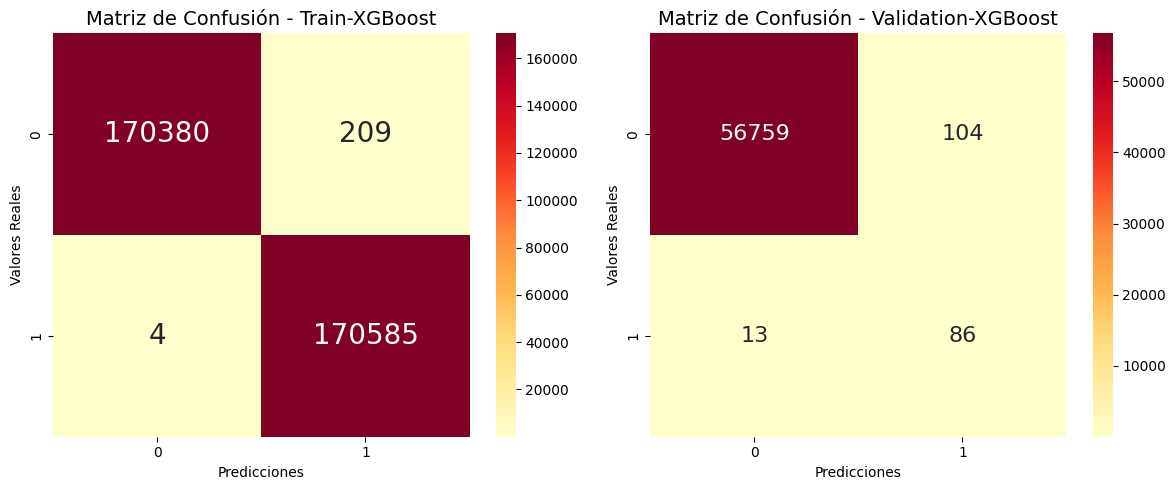

,XGBoost_train,XGBoost_validation
accuracy,0.959322,0.974895
recall,0.925424,0.887755
specificity,0.993220,0.975045
precision,0.992727,0.057769
f1,0.957895,0.108479


In [35]:
#Modelo seleccionado para comparar contra redes neuronales: modelo_xgb_SF
metricas_XGB_3 = evaluacion_modelo(modelo_xgb_SF, X_train_bal2, y_train_bal2, X_test, y_test, nombre_modelo = "XGBoost", graficar = True)
metricas_XGB

In [36]:
#Creación redes neuronales

In [37]:
from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
#Se define el modelo secuencial
model = Sequential()
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Para clasificación binaria
# Compilar el modelo
model.compile(loss='binary_crossentropy', # clasificación binaria  // multiclase: categorialcrossentropy // regresión : mse
              optimizer='adam',
              metrics=['accuracy'])
# Calcular pesos automáticamente
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
# Entrenar el modelo usando el conjunto de validación explícitamente
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    class_weight = class_weight_dict,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9749 - loss: 0.2295 - val_accuracy: 0.9639 - val_loss: 0.1665
Epoch 2/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9772 - loss: 0.1429 - val_accuracy: 0.9818 - val_loss: 0.0917
Epoch 3/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9813 - loss: 0.1318 - val_accuracy: 0.9740 - val_loss: 0.1049
Epoch 4/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9790 - loss: 0.1050 - val_accuracy: 0.9828 - val_loss: 0.0769
Epoch 5/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9800 - loss: 0.0936 - val_accuracy: 0.9931 - val_loss: 0.0424
Epoch 6/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9808 - loss: 0.0918 - val_accuracy: 0.9823 - val_loss: 0.0680
Epoch 7/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9820 - loss: 0.0821 - val_accuracy: 0.9769 - val_loss: 0.0815
Epoch 8/10
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9792 - loss: 0

In [38]:
# 5. Evaluar el modelo
print("\n--- Evaluación ---")
print("Pérdida y Accuracy en entrenamiento:", model.evaluate(X_train, y_train))
print("Pérdida y Accuracy en validación:  ", model.evaluate(X_val, y_val))
print("Pérdida y Accuracy en prueba (test):", model.evaluate(X_test, y_test))


--- Evaluación ---
5341/5341 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9738 - loss: 0.0794
Pérdida y Accuracy en entrenamiento: [0.07942532002925873, 0.9737951159477234]
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9733 - loss: 0.0852
Pérdida y Accuracy en validación:   [0.08522269874811172, 0.9732624292373657]
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9733 - loss: 0.0827
Pérdida y Accuracy en prueba (test): [0.08271276205778122, 0.9733331203460693]


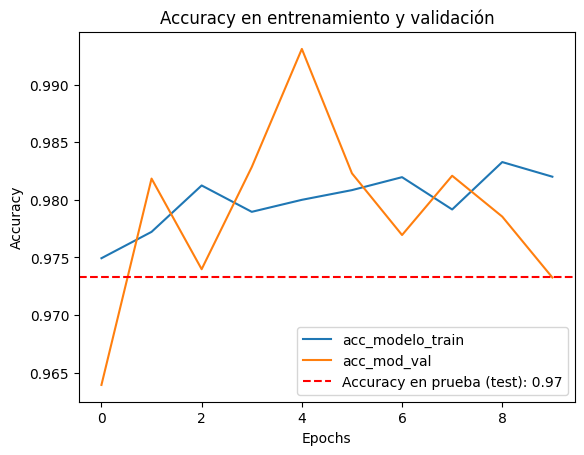

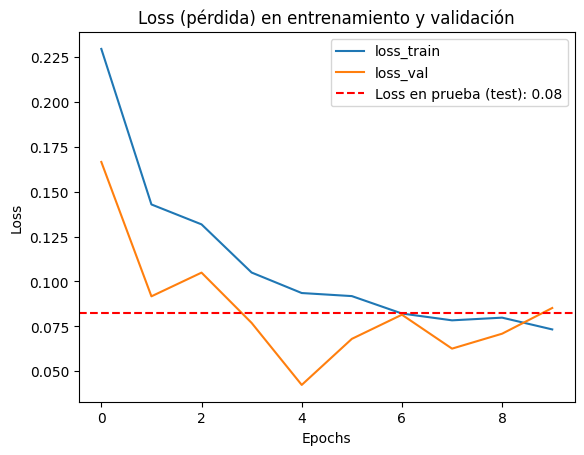

In [39]:
# Gráfica del accuracy del modelo en train y test
loss_test, acc_test = model.evaluate(X_test, y_test, verbose=0)
plt.plot(history.history['accuracy'], label = "acc_modelo_train")
plt.plot(history.history['val_accuracy'], label = "acc_mod_val")
plt.axhline(y=acc_test, color='r', linestyle='--', label=f"Accuracy en prueba (test): {acc_test:.2f}")
plt.title("Accuracy en entrenamiento y validación")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Gráfica de la pérdida en test y train
plt.plot(history.history['loss'], label = "loss_train")
plt.plot(history.history['val_loss'], label = "loss_val")
plt.axhline(y=loss_test, color='r', linestyle='--', label=f"Loss en prueba (test): {loss_test:.2f}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss (pérdida) en entrenamiento y validación")
plt.legend()
plt.show()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


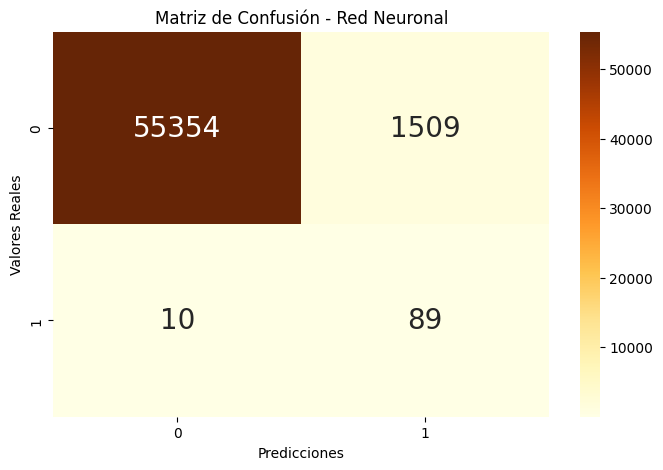


--- Métricas ---
Accuracy : 0.9733
Recall   : 0.8990
Precision: 0.0557
F1 Score : 0.1049


In [40]:
#Evaluamos con Y_test
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,5))
sns.heatmap(
    pd.DataFrame(cm),
    annot=True,
    annot_kws={'size':20},
    cmap='YlOrBr',
    fmt='g'
)
plt.title('Matriz de Confusión - Red Neuronal')
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()
# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("\n--- Métricas ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score : {f1:.4f}")

In [41]:
roc_auc = roc_auc_score(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"AP Score: {ap_score:.4f}")

ROC-AUC : 0.9777
AP Score: 0.7635


In [42]:
#Mejor que UnderSampling
#Peor que ambos SMOTE

In [43]:
#Comparación final

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


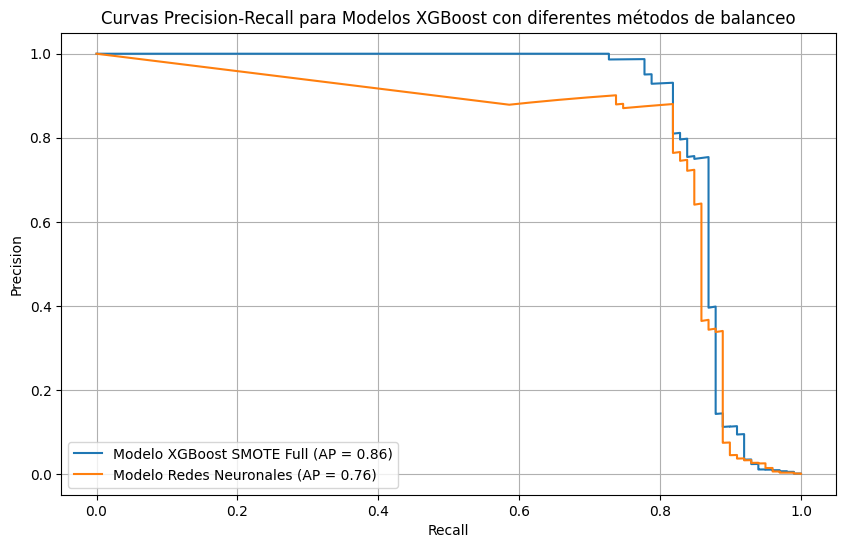

In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

#Precision-Recall Curve para los 3 modelos XGB con 3 diferentes metodos de balanceo
plt.figure(figsize=(10, 6))

# Modelo 1: modelo_xgb_SF (SMOTE full)
y_prob_1 = modelo_xgb_SF.predict_proba(X_test)[:, 1]
precision_1, recall_1, _ = precision_recall_curve(y_test, y_prob_1)
ap_score_1 = average_precision_score(y_test, y_prob_1)
plt.plot(recall_1, precision_1, label=f'Modelo XGBoost SMOTE Full (AP = {ap_score_1:.2f})')

# Modelo 2: Redes neuronales
y_prob_2 = model.predict(X_test).ravel()
precision_2, recall_2, _ = precision_recall_curve(y_test, y_prob_2)
ap_score_2 = average_precision_score(y_test, y_prob_2)
plt.plot(recall_2, precision_2, label=f'Modelo Redes Neuronales (AP = {ap_score_2:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall para Modelos XGBoost con diferentes métodos de balanceo')
plt.legend(loc='best')
plt.grid(True)
plt.show()

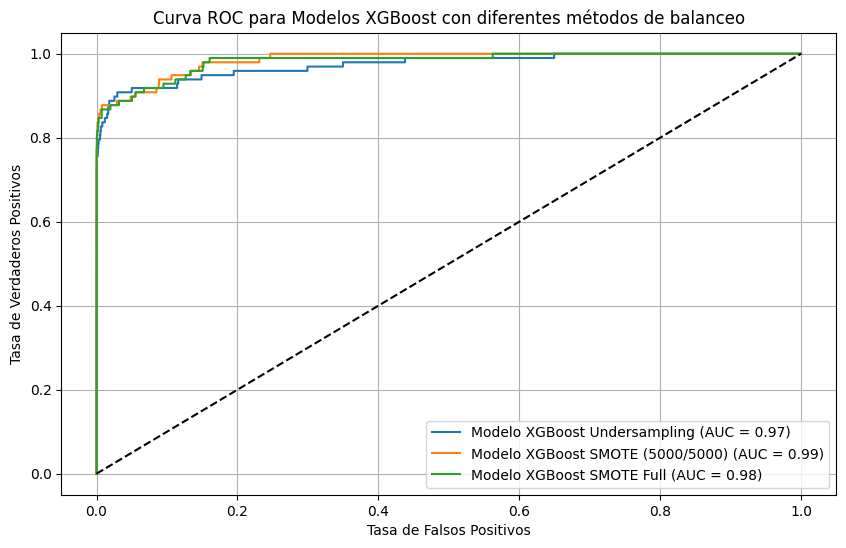

In [45]:
# CÁLCULO DE ROC Y AUC EN VALIDATION
# Curva ROC - Validation
fpr_xgb_256, tpr_xgb_256, _ = roc_curve(y_val, modelo_XGB.predict_proba(X_val)[:, 1])
fpr_xgb_5000, tpr_xgb_5000, _ = roc_curve(y_val, modelo_xgb_5000.predict_proba(X_val)[:, 1])
fpr_xgb_SF, tpr_xgb_SF, _ = roc_curve(y_val, modelo_xgb_SF.predict_proba(X_val)[:, 1])
# AUC - Validation
auc_xgb_256 = roc_auc_score(y_val, modelo_XGB.predict_proba(X_val)[:, 1])
auc_xgb_5000 = roc_auc_score(y_val, modelo_xgb_5000.predict_proba(X_val)[:, 1])
auc_xgb_SF = roc_auc_score(y_val, modelo_xgb_SF.predict_proba(X_val)[:, 1])
# GRÁFICA CURVA ROC - VALIDATION
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb_256, tpr_xgb_256, label=f'Modelo XGBoost Undersampling (AUC = {auc_xgb_256:.2f})')
plt.plot(fpr_xgb_5000, tpr_xgb_5000, label=f'Modelo XGBoost SMOTE (5000/5000) (AUC = {auc_xgb_5000:.2f})')
plt.plot(fpr_xgb_SF, tpr_xgb_SF, label=f'Modelo XGBoost SMOTE Full (AUC = {auc_xgb_SF:.2f})')
# Línea diagonal (azar)
plt.plot([0, 1], [0, 1], 'k--')
# Detalles del gráfico
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Modelos XGBoost con diferentes métodos de balanceo')
plt.legend(loc='best')
plt.grid(True)
plt.show()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


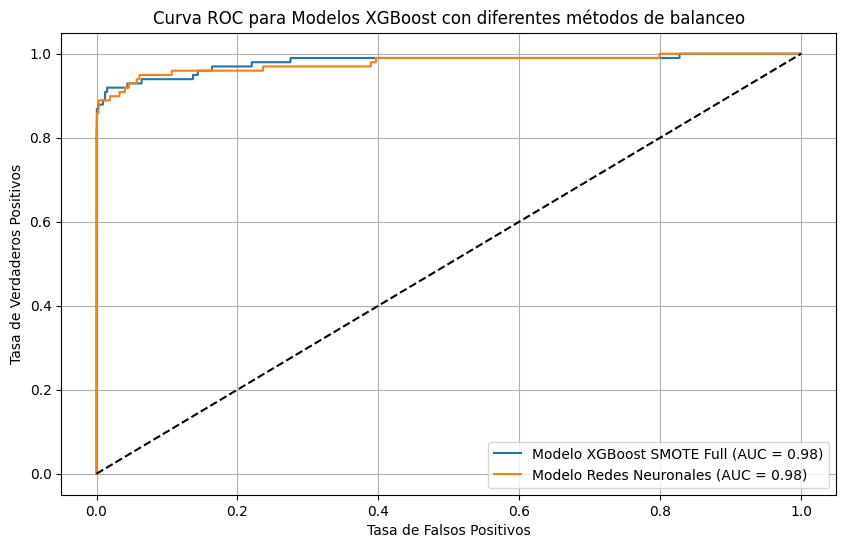

In [46]:
# CÁLCULO DE ROC Y AUC EN TEST
fpr_xgb_SF, tpr_xgb_SF, _ = roc_curve(y_test, modelo_xgb_SF.predict_proba(X_test)[:, 1])
fpr_model, tpr_model, _ = roc_curve(y_test, model.predict(X_test).ravel())
# AUC - TEST
auc_xgb_SF = roc_auc_score(y_test, modelo_xgb_SF.predict_proba(X_test)[:, 1])
auc_model = roc_auc_score(y_test, model.predict(X_test).ravel())
# GRÁFICA CURVA ROC - VALIDATION
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb_SF, tpr_xgb_SF, label=f'Modelo XGBoost SMOTE Full (AUC = {auc_xgb_SF:.2f})')
plt.plot(fpr_model, tpr_model, label=f'Modelo Redes Neuronales (AUC = {auc_model:.2f})')
# Línea diagonal (azar)
plt.plot([0, 1], [0, 1], 'k--')
# Detalles del gráfico
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Modelos XGBoost con diferentes métodos de balanceo')
plt.legend(loc='best')
plt.grid(True)
plt.show()

El modelo XGBoost entrenado con SMOTE Full alcanzó un Average Precision de 0.86 y un ROC-AUC de 0.98, superando a la red neuronal evaluada. Los resultados sugieren que los métodos basados en árboles son especialmente efectivos para datos tabulares altamente desbalanceados, permitiendo detectar transacciones fraudulentas con una mejor relación entre detecciones correctas y falsas alarmas.
